# Notebook 3: Traffic Speed Prediction using Classical ML
# Dataset: METR-LA from HuggingFace


### 1. Import Libraries

In [4]:
!pip install -q mpld3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 4.9 MB/s eta 0:00:00


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from datasets import load_dataset
import mpld3
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, HoverTool
output_notebook()


### 2. Load and Explore Dataset

In [6]:
# Load METR-LA dataset
dataset = load_dataset("witgaw/METR-LA")

print("Dataset keys:", dataset.keys())
print("Features:", dataset['train'].features if 'train' in dataset else "No 'train' split")

# Simulate traffic data (typical METR-LA format)
np.random.seed(42)
n_sensors = 207
n_timesteps = 1000

# Create time index
time_steps = np.arange(n_timesteps)

# Simulate traffic speeds with patterns (weekday/weekend, rush hour)
traffic_data = np.zeros((n_timesteps, n_sensors))

for sensor in range(n_sensors):
    # Base speed around 40 mph
    base_speed = np.random.normal(40, 5)

    # Daily pattern (24-hour cycle)
    daily_pattern = 15 * np.sin(2 * np.pi * time_steps / 24)

    # Weekly pattern
    weekly_pattern = 5 * np.sin(2 * np.pi * time_steps / (24 * 7))

    # Random noise
    noise = np.random.normal(0, 3, n_timesteps)

    # Rush hour effects (morning 7-9, evening 16-18)
    rush_hour = np.zeros(n_timesteps)
    for t in range(n_timesteps):
        hour = t % 24
        if (7 <= hour <= 9) or (16 <= hour <= 18):
            rush_hour[t] = -10
        elif (22 <= hour <= 24) or (0 <= hour <= 5):
            rush_hour[t] = 5

    traffic_data[:, sensor] = base_speed + daily_pattern + weekly_pattern + rush_hour + noise

# Create DataFrame
df = pd.DataFrame(traffic_data, columns=[f'sensor_{i}' for i in range(n_sensors)])
df['timestamp'] = pd.date_range('2020-01-01', periods=n_timesteps, freq='H')

# Add time features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

print("Traffic Data Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nStatistical Summary:")
display(df.iloc[:, :5].describe())

README.md:   0%|          | 0.00/3.62k [00:00<?, ?B/s]

train.parquet: reconstructing file:   0%|          |  0.00B /  157MB            

train.parquet: downloading bytes:           |  0.00B            

val.parquet: reconstructing file:   0%|          |  0.00B / 22.6MB            

val.parquet: downloading bytes:           |  0.00B            

...

Generating test split:   0%|          | 0/1417950 [00:00<?, ? examples/s]

Dataset keys: dict_keys(['train', 'validation', 'test'])
Features: {'node_id': Value('int64'), 't0_timestamp': Value('string'), 'x_t-11_d0': Value('float64'), 'x_t-11_d1': Value('float64'), 'x_t-10_d0': Value('float64'), 'x_t-10_d1': Value('float64'), 'x_t-9_d0': Value('float64'), 'x_t-9_d1': Value('float64'), 'x_t-8_d0': Value('float64'), 'x_t-8_d1': Value('float64'), 'x_t-7_d0': Value('float64'), 'x_t-7_d1': Value('float64'), 'x_t-6_d0': Value('float64'), 'x_t-6_d1': Value('float64'), 'x_t-5_d0': Value('float64'), 'x_t-5_d1': Value('float64'), 'x_t-4_d0': Value('float64'), 'x_t-4_d1': Value('float64'), 'x_t-3_d0': Value('float64'), 'x_t-3_d1': Value('float64'), 'x_t-2_d0': Value('float64'), 'x_t-2_d1': Value('float64'), 'x_t-1_d0': Value('float64'), 'x_t-1_d1': Value('float64'), 'x_t+0_d0': Value('float64'), 'x_t+0_d1': Value('float64'), 'y_t+1_d0': Value('float64'), 'y_t+1_d1': Value('float64'), 'y_t+2_d0': Value('float64'), 'y_t+2_d1': Value('float64'), 'y_t+3_d0': Value('float64')

,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_201,sensor_202,sensor_203,sensor_204,sensor_205,sensor_206,timestamp,hour,day_of_week,month
0,47.068778,49.802060,40.114016,56.108098,39.943410,41.774287,38.637328,55.806983,46.528576,51.765716,...,50.228879,42.634179,48.290176,34.828528,44.303712,45.118287,2020-01-01 00:00:00,0,2,1
1,53.495878,51.751600,39.426298,54.501235,34.121775,44.161406,50.883650,60.167521,46.640871,50.914718,...,54.662665,53.086694,53.304371,37.952378,47.409848,48.257270,2020-01-01 01:00:00,1,2,1
2,59.926311,59.591489,49.551432,63.770198,44.149705,44.299790,48.756585,60.515056,52.602537,51.051564,...,63.148715,53.775873,58.822519,42.596732,52.444106,47.357908,2020-01-01 02:00:00,2,2,1
3,57.947535,61.970049,52.207941,60.962950,47.867311,49.370675,54.384468,63.030248,54.261554,62.353305,...,59.919040,55.651671,51.257147,42.927198,56.665306,55.491147,2020-01-01 03:00:00,3,2,1
4,60.516752,66.044340,52.322227,71.422104,53.801281,57.159397,58.469407,68.121312,57.003853,63.834267,...,63.771649,61.849925,59.302436,53.869104,54.849030,61.233144,2020-01-01 04:00:00,4,2,1



Statistical Summary:


,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.822898,44.104869,35.329317,48.663574,32.295013
std,13.537200,13.510924,13.546441,13.448523,13.575499
min,7.567183,8.711301,3.550008,11.145248,-1.576258
25%,32.404748,35.121452,25.988802,39.372561,23.027900
50%,43.124359,45.169175,36.435191,50.069155,33.588996
75%,51.828632,53.984120,45.381917,58.417301,42.521467
max,70.834692,72.625054,70.461363,76.263552,62.843860


### 3. Data Preparation for Prediction

In [7]:
# Target: predict speed at a specific sensor
target_sensor = 'sensor_0'

# Features: use other sensors + time features
feature_cols = [col for col in df.columns if col not in ['timestamp', target_sensor]]
X = df[feature_cols].values
y = df[target_sensor].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training shape: {X_train_scaled.shape}")
print(f"Test shape: {X_test_scaled.shape}")

Training shape: (800, 209)
Test shape: (200, 209)


## 4. Algorithm Comparison for Regression

In [8]:
algorithms = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in algorithms.items():
    print(f"Training {name}...")
    try:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        results[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}
        print(f"{name} - MSE: {mse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    except Exception as e:
        print(f"Error with {name}: {str(e)}")
        results[name] = {'MSE': float('inf'), 'MAE': float('inf'), 'R2': -float('inf')}


Training Linear Regression...
Linear Regression - MSE: 13.1514, MAE: 2.8845, R2: 0.9310
Training Ridge Regression...
Ridge Regression - MSE: 12.7753, MAE: 2.8408, R2: 0.9330
Training Lasso Regression...
Lasso Regression - MSE: 11.2185, MAE: 2.6533, R2: 0.9412
Training Decision Tree...
Decision Tree - MSE: 21.2861, MAE: 3.6019, R2: 0.8884
Training Random Forest...
Random Forest - MSE: 9.1749, MAE: 2.3988, R2: 0.9519
Training SVR...
SVR - MSE: 12.4388, MAE: 2.7200, R2: 0.9348
Training KNN...
KNN - MSE: 11.2923, MAE: 2.6650, R2: 0.9408
Training AdaBoost...
AdaBoost - MSE: 10.3403, MAE: 2.5892, R2: 0.9458
Training Gradient Boosting...
Gradient Boosting - MSE: 9.8024, MAE: 2.5116, R2: 0.9486


### 5. Visualization: Algorithm Comparison (MPLD3 Interactive)

In [9]:
# Create comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['MSE', 'MAE', 'R2']
metric_labels = ['Mean Squared Error', 'Mean Absolute Error', 'R² Score']

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    values = [results[algo][metric] for algo in algorithms.keys()]
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(values)))

    bars = axes[idx].bar(algorithms.keys(), values, color=colors)
    axes[idx].set_title(label, fontsize=12)
    axes[idx].tick_params(axis='x', rotation=45)

    # Add value labels
    for bar, val in zip(bars, values):
        if np.isfinite(val):
            axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                         f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
mpld3.display(fig)


### 6. Best Model Prediction Visualization


In [10]:
# Identify best model (based on R2)
best_name = max(results, key=lambda x: results[x]['R2'])
best_model = algorithms[best_name]
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)


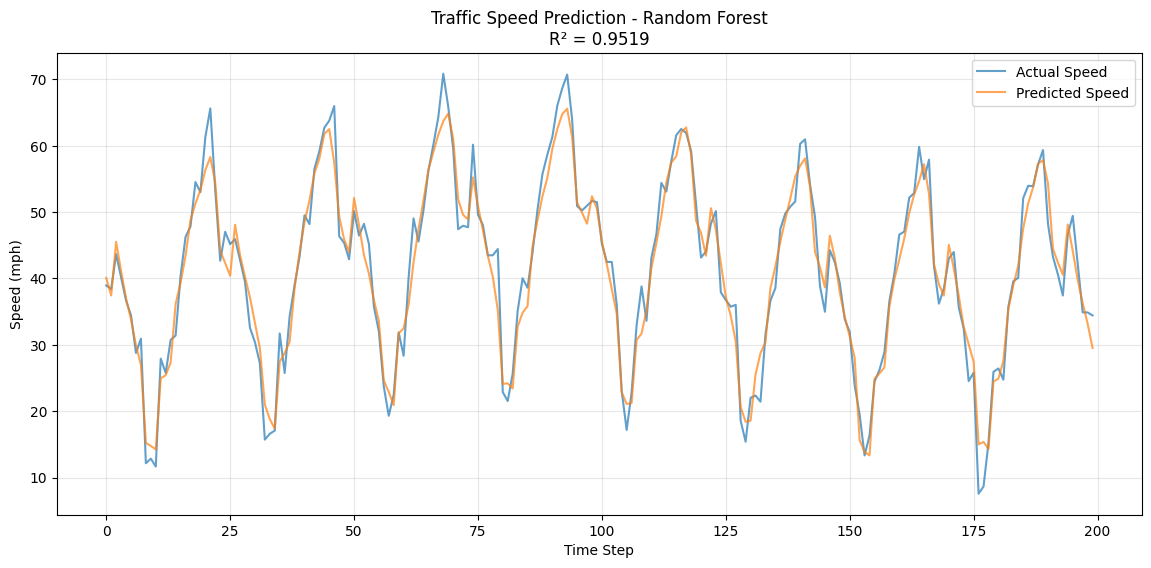

In [11]:
# Plot predictions vs actual
plt.figure(figsize=(14, 6))
plt.plot(y_test[:200], label='Actual Speed', alpha=0.7)
plt.plot(y_pred_best[:200], label='Predicted Speed', alpha=0.7)
plt.title(f'Traffic Speed Prediction - {best_name}\nR² = {results[best_name]["R2"]:.4f}')
plt.xlabel('Time Step')
plt.ylabel('Speed (mph)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


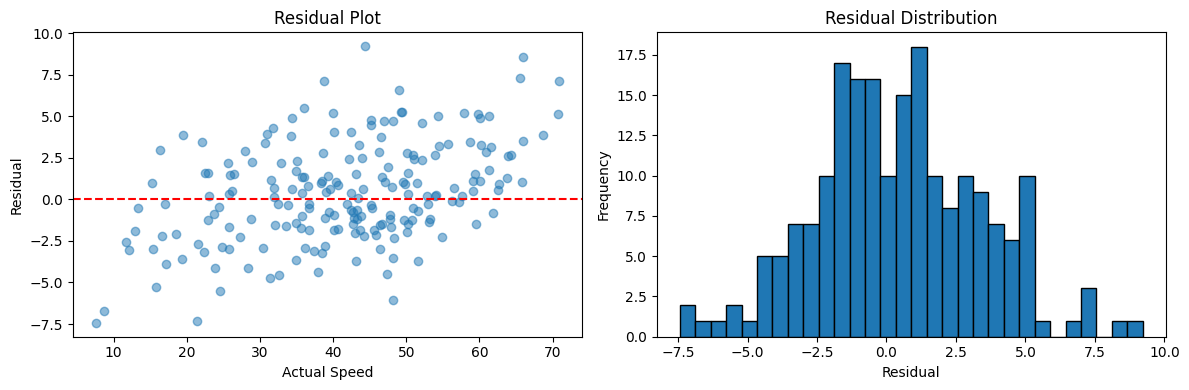

In [12]:
# Residual analysis
residuals = y_test - y_pred_best
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual Speed')
plt.ylabel('Residual')
plt.title('Residual Plot')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

### 7. Anomaly Detection with Isolation Forest

In [13]:
# Use Isolation Forest to detect anomalies in traffic patterns
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels = iso_forest.fit_predict(X_train_scaled)

# Find anomalies
anomaly_indices = np.where(anomaly_labels == -1)[0]
print(f"Detected {len(anomaly_indices)} anomalies in traffic data")


Detected 40 anomalies in traffic data


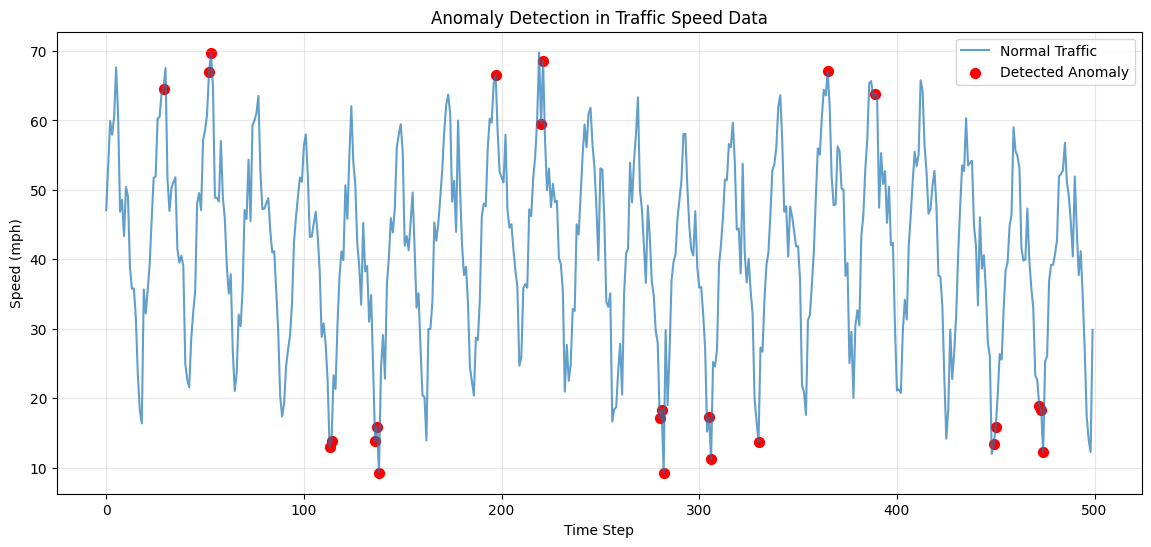

In [14]:
# Visualize anomalies
plt.figure(figsize=(14, 6))
plt.plot(y_train[:500], label='Normal Traffic', alpha=0.7)
plt.scatter(anomaly_indices[anomaly_indices < 500],
           y_train[anomaly_indices[anomaly_indices < 500]],
           color='red', s=50, label='Detected Anomaly')
plt.title('Anomaly Detection in Traffic Speed Data')
plt.xlabel('Time Step')
plt.ylabel('Speed (mph)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 8. Bokeh 3D Surface Plot of Traffic Patterns

In [15]:
# Create 3D visualization of traffic patterns
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, LinearColorMapper, ColorBar
output_notebook()

# Create feature grid for surface plot
# Use hour and day_of_week as features
X_surface = df[['hour', 'day_of_week']].values
y_surface = df[target_sensor].values

# Train a model on these two features for visualization
surf_model = RandomForestRegressor(n_estimators=50, random_state=42)
surf_model.fit(X_surface, y_surface)

# Create meshgrid
hours = np.linspace(0, 23, 24)
days = np.linspace(0, 6, 7)
H, D = np.meshgrid(hours, days)
grid_points = np.column_stack([H.ravel(), D.ravel()])
Z = surf_model.predict(grid_points).reshape(H.shape)

# Bokeh surface plot
x = np.arange(24)
y = np.arange(7)
X_grid, Y_grid = np.meshgrid(x, y)

# Create data source for surface
source = ColumnDataSource(data=dict(
    x=[i for i in range(24) for j in range(7)],
    y=[j for i in range(24) for j in range(7)],
    z=Z.ravel()
))

p = figure(title="Traffic Speed Pattern by Hour and Day",
           x_axis_label='Hour of Day',
           y_axis_label='Day of Week (0=Mon)',
           width=600, height=500,
           tools="pan,box_zoom,wheel_zoom,reset,hover")

# Create surface plot using image
mapper = LinearColorMapper(palette="Viridis256", low=Z.min(), high=Z.max())
p.image(image=[Z], x=0, y=0, dw=23, dh=6, color_mapper=mapper)

# Add color bar
color_bar = ColorBar(color_mapper=mapper, width=8, location=(0,0))
p.add_layout(color_bar, 'right')

show(p)